In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df_instacart.shape

(1384706, 22)

In [5]:
type(df_instacart.columns)

pandas.Index

In [14]:
orders_by_day = (
   df_instacart[["order_id", "order_dow"]]
   .drop_duplicates()
   .groupby("order_dow")
   .size() 
)
orders_by_day

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

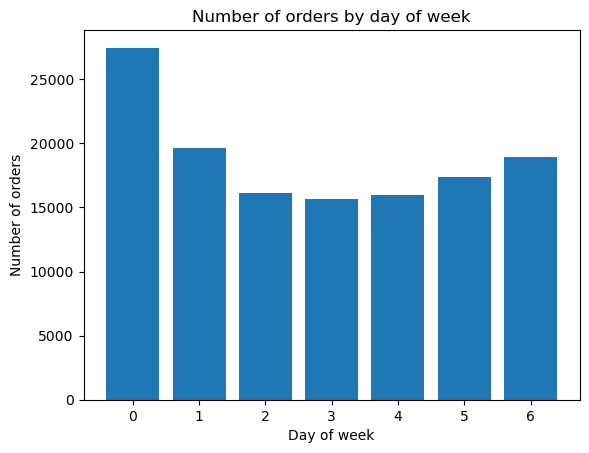

In [10]:
plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.title("Number of orders by day of week")
plt.xlabel("Day of week")
plt.ylabel("Number of orders")
plt.show()

### Our first real matplotlib chart using the project data

In [15]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)
orders_by_hour

order_hour_of_day
0       852
1       507
2       305
3       223
4       218
5       402
6      1121
7      3376
8      6343
9      9033
10    10585
11    10610
12    10622
13    10711
14    11103
15    11075
16    10495
17     9353
18     7558
19     5721
20     3978
21     3050
22     2442
23     1526
dtype: int64

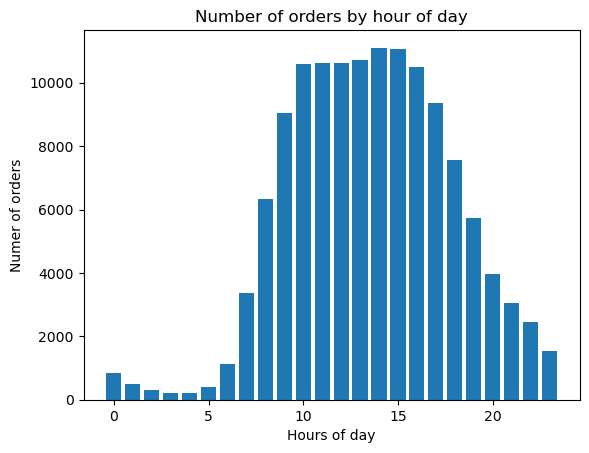

In [16]:
plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of orders by hour of day")
plt.xlabel("Hours of day")
plt.ylabel("Numer of orders")
plt.show()


In [21]:
top_departments = df_instacart["department"].value_counts().head()
top_departments

department
produce       409087
dairy eggs    217051
snacks        118862
beverages     113962
frozen        100426
Name: count, dtype: int64

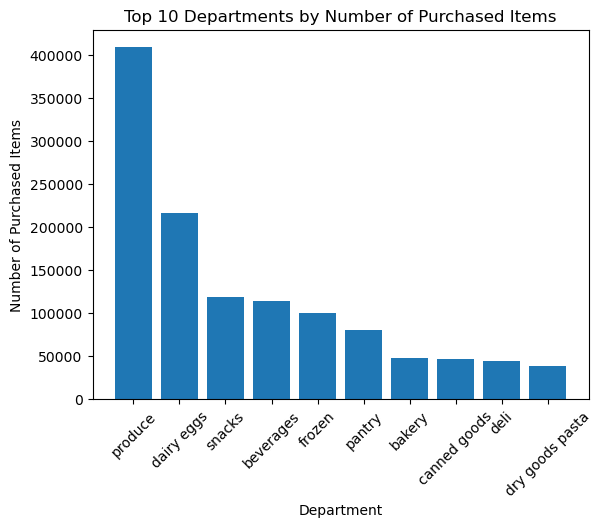

In [22]:
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()

### իսկ հիմա փոխենք x, y տեղերը, կտեսնենք, արդյունքում ավելի հարմար է վիզուալիզացիան

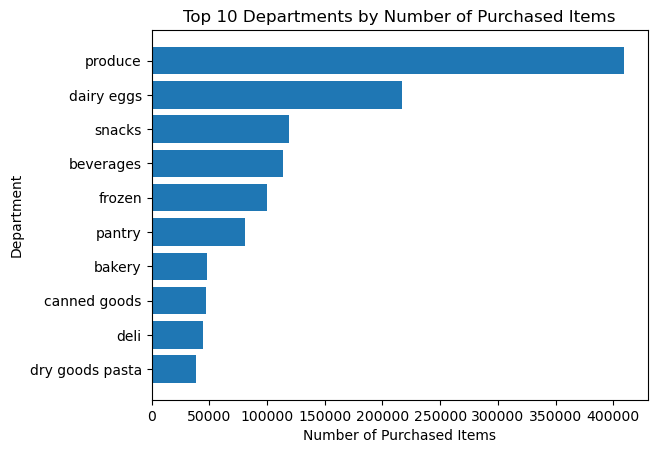

In [23]:
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()

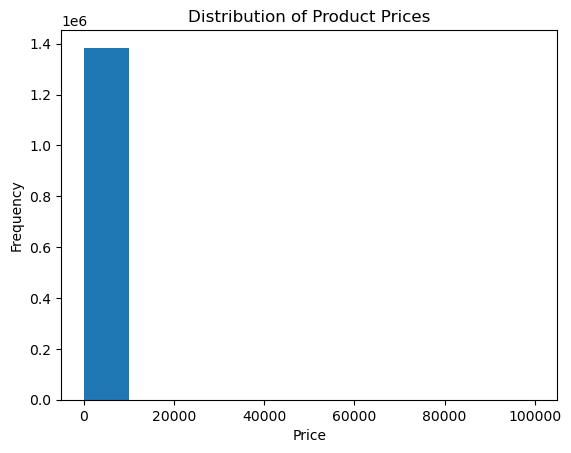

In [25]:
df_instacart["prices"].describe()

plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=10)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()